In [52]:
# basic tools
import os
os.environ["OMP_NUM_THREADS"] = "1" # Specificaly for small data set tto avoid memory leak

import numpy as np
import pandas as pd
import duckdb # Data base

#Visual tools
import seaborn as sns
import matplotlib.pyplot as plt
from adjustText import adjust_text
import plotly.express as px
import plotly.graph_objects as go

#Analysis tools
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster.hierarchy import linkage, dendrogram
import scipy.stats as stats
from scipy.integrate import trapezoid
import sklearn.model_selection as skm
from sklearn.ensemble import RandomForestRegressor as RFR

In [2]:
# Connect to a database file 
con = duckdb.connect('../aav_manufacturing.db') 

# Post-Production Analysis

## Calculating derived variables from raw data

In [3]:
query = """SELECT * FROM telemetry_aligned """
df_aligned = con.execute(query).df()

# Calculate instantaneous rates in the aligned dataframe
df_aligned = df_aligned.sort_values(['Batch_ID', 'Hour'])
df_aligned['dt'] = df_aligned.groupby('Batch_ID')['Hour'].diff()

# Growth Rate (mu): (ΔVCD / VCD) / Δt
df_aligned['Growth_Rate'] = df_aligned.groupby('Batch_ID')['VCD'].diff() / (df_aligned['VCD'] * df_aligned['dt'])

# Specific Production Rate (qp): ΔP / (VCD * Δt)
df_aligned['Production_Rate'] = df_aligned.groupby('Batch_ID')['Product'].diff() / (df_aligned['VCD'] * df_aligned['dt'])

# Specific Consumption Rate (qg): ΔG / (VCD * Δt)
df_aligned['Consumption_Rate'] = df_aligned.groupby('Batch_ID')['Glucose'].diff() / (df_aligned['VCD'] * df_aligned['dt'])

# Register with DuckDB
con.register('telemetry_aligned', df_aligned)

## Agregating required data for analysis

In [4]:
query = """
SELECT 
    o.Batch_ID, 
    o.Status, 
    o.Full_Titer, 
    MAX(t.Ammonia) AS Max_Ammonia,
    MAX(t.Lactate) AS Max_Lactate,
    MIN(t.pH) AS Min_pH,
    AVG(CASE WHEN t.Hour >= 0 THEN t.Growth_Rate END) AS Avg_Growth_Rate,
    AVG(CASE WHEN t.Hour >= 72 THEN t.Production_Rate END) AS Avg_Prod_Rate,
    AVG(CASE WHEN t.Hour >= 0 THEN t.Consumption_Rate END) AS Avg_Gluc_Cons
FROM outcomes o
JOIN telemetry_aligned t ON o.Batch_ID = t.Batch_ID
GROUP BY o.Batch_ID, o.Status, o.Full_Titer
"""

df_pca_final = con.execute(query).df()


## First PCA for relevant Principal Components

In [5]:
# Define features for the model
feature_cols = ['Max_Ammonia', 'Max_Lactate', 'Min_pH', 
                'Avg_Growth_Rate', 'Avg_Prod_Rate', 'Avg_Gluc_Cons']

# Handle missing values (if any rates couldn't be calculated)
df_pca_final = df_pca_final.dropna(subset=feature_cols)

# Scale the data (Mandatory for PCA)
scaler = StandardScaler()
X = scaler.fit_transform(df_pca_final[feature_cols])

In [6]:
# Run PCA
pca = PCA(n_components=5)
principal_components = pca.fit_transform(X)

# Store results for visualization
df_pca_plot = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2','PC3','PC4','PC5'])
df_pca_plot['Status'] = df_pca_final['Status'].values

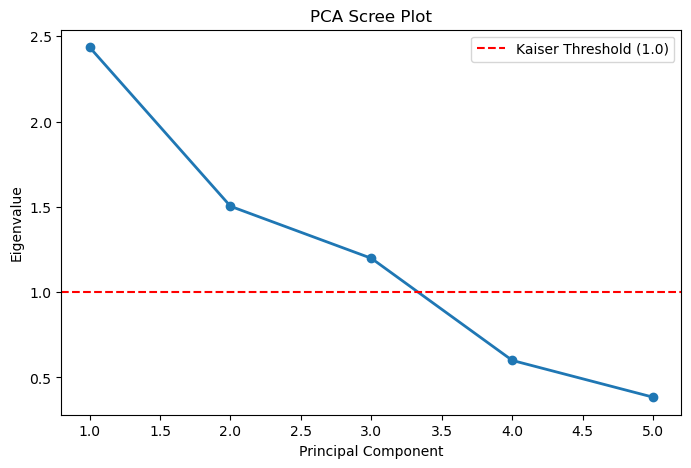

In [7]:
# Calculate Eigenvalues
eigenvalues = pca.explained_variance_

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(eigenvalues) + 1), eigenvalues, 'o-', linewidth=2)
plt.axhline(y=1, color='r', linestyle='--', label='Kaiser Threshold (1.0)')
plt.title('PCA Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Eigenvalue')
plt.legend()
plt.show()

## Second PCA for visualization and clustering analysis

In [8]:
# Run PCA
pca = PCA(n_components=3)
principal_components = pca.fit_transform(X)

# Store results for visualization
df_pca_plot = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2', 'PC3'])
df_pca_plot['Status'] = df_pca_final['Status'].values

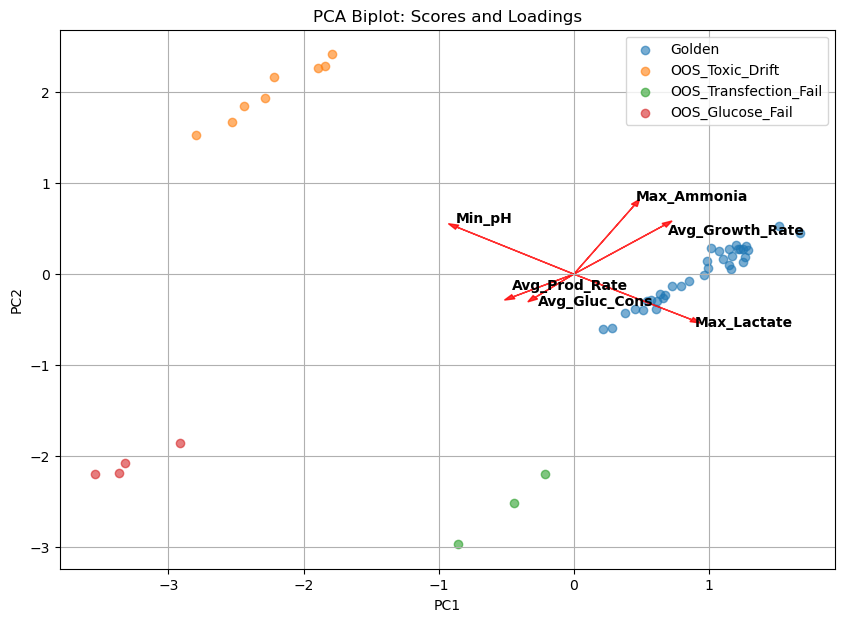

In [9]:
# Extract loadings
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

# Create Biplot
plt.figure(figsize=(10, 7))

# Plot the scores (the batches)
for status in df_pca_final['Status'].unique():
    mask = df_pca_final['Status'] == status
    plt.scatter(principal_components[mask, 0], principal_components[mask, 1], label=status, alpha=0.6)

texts = []
for i, feature in enumerate(feature_cols):
    texts.append(plt.text(loadings[i, 0], loadings[i, 1], feature, fontweight='bold'))
    plt.arrow(0, 0, loadings[i, 0], loadings[i, 1], color='r', alpha=0.8, head_width=0.05)
# This function iteratively moves text to avoid overlaps
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='red', lw=0.5))


plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA Biplot: Scores and Loadings')
plt.legend()
plt.grid(True)
plt.show()

## Golden batch threshold

In [10]:
# 1. Fit PCA ONLY on Golden Batches to define the 'Normal' space
golden_mask = df_pca_final['Status'] == 'Golden'
p_components = 3
pca_golden = PCA(n_components=p_components)
scaler = StandardScaler()

train_scaled = scaler.fit_transform(df_pca_final[golden_mask][feature_cols])
pca_golden.fit(train_scaled)

# 2. Project ALL batches (Golden + OOS) into this 'Golden Space'
all_scaled = scaler.transform(df_pca_final[feature_cols])
scores = pca_golden.transform(all_scaled)

eigenvalues = pca_golden.explained_variance_
t2_values = np.sum((scores**2) / eigenvalues, axis=1)

# 2. Calculate the 99% Confidence Threshold (UCL - Upper Control Limit)
# n: number of golden batches used for training
# p: number of PCs retained 
n = df_pca_final[golden_mask].shape[0]
p = p_components
alpha = 0.01
t2_threshold = (p * (n - 1) / (n - p)) * stats.f.ppf(1 - alpha, p, n - p)

# 3. Assign T2 to the dataframe for plotting
df_pca_final['T2_Statistic'] = t2_values
df_pca_final['OOS_Threshold'] = t2_threshold
df_pca_final['Alarm'] = df_pca_final['T2_Statistic'] > df_pca_final['OOS_Threshold']

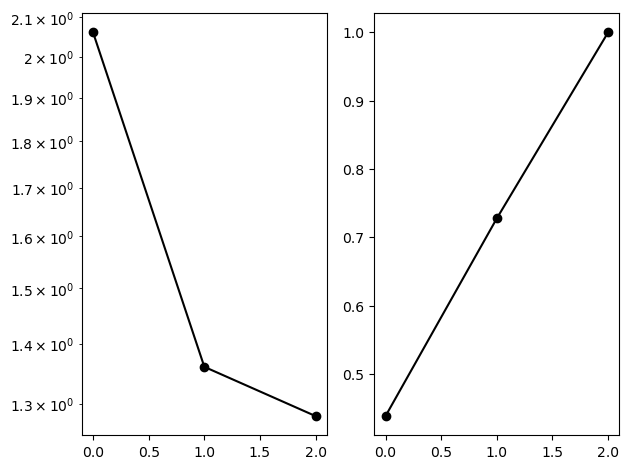

In [12]:
fig1 = plt.figure()
ax1 = fig1.add_subplot(121)
ax1.semilogy(eigenvalues,'-o',color='k')
ax2 = fig1.add_subplot(122)
ax2.plot(np.cumsum(eigenvalues)/np.sum(eigenvalues),'-o',color='k')

plt.tight_layout()
plt.show()

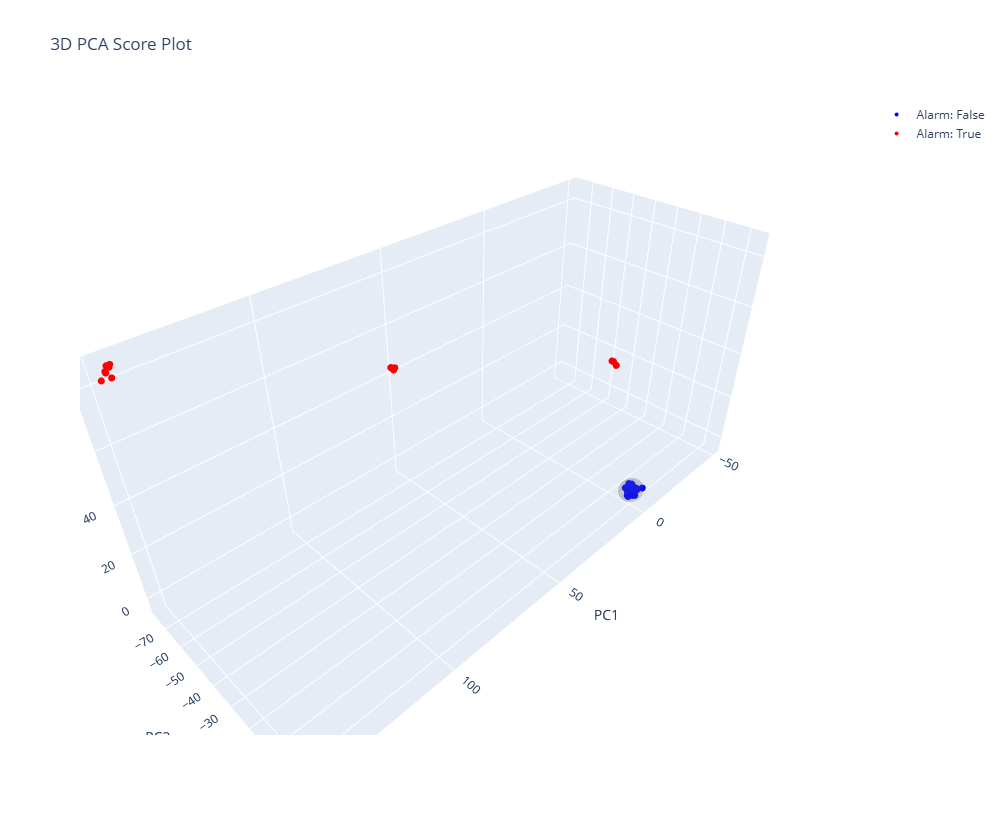

In [13]:
# Representing the PCA space and batches within this space

df_plot = pd.DataFrame(scores, columns=["PC1", "PC2", "PC3"])
df_plot['Alarm'] = df_pca_final['Alarm'].values
df_plot['Status'] = df_pca_final['Status'].values

eigenvalues = pca_golden.explained_variance_
radius_x = np.sqrt(t2_threshold * eigenvalues[0])
radius_y = np.sqrt(t2_threshold * eigenvalues[1])
radius_z = np.sqrt(t2_threshold * eigenvalues[2])

# 3. Create the Ellipse Shape
phi = np.linspace(0, np.pi, 50)
theta = np.linspace(0, 2 * np.pi, 50)
phi, theta = np.meshgrid(phi, theta)

x_ellipse = radius_x * np.sin(phi) * np.cos(theta)
y_ellipse = radius_y * np.sin(phi) * np.sin(theta)
z_ellipse = radius_z * np.cos(phi)


fig = go.Figure()

for alarm_val, color in zip([False, True], ['blue', 'red']):
    mask = df_plot['Alarm'] == alarm_val
    fig.add_trace(go.Scatter3d(
        x=df_plot.loc[mask, 'PC1'],
        y=df_plot.loc[mask, 'PC2'],
        z=df_plot.loc[mask, 'PC3'],
        mode='markers',
        marker=dict(size=4, color=color),
        name=f'Alarm: {alarm_val}'
    ))

fig.add_trace(go.Surface(
    x=x_ellipse, y=y_ellipse, z=z_ellipse,
    opacity=0.2,
    showscale=False,
    colorscale=[[0, 'gray'], [1, 'gray']],
    name='95% T2 Ellipsoid'
))

fig.update_layout(
    scene=dict(
        xaxis_title='PC1',
        yaxis_title='PC2',
        zaxis_title='PC3'
    ),
    title="3D PCA Score Plot with Hotelling T2 Ellipsoid"
)

fig.update_layout(
    width=1200,
    height=800,
    scene=dict(
        xaxis_title='PC1',
        yaxis_title='PC2',
        zaxis_title='PC3'
    ),
    title="3D PCA Score Plot"
)
fig.show()

In [14]:
# Reconstruct the data from the PCA space
# This tries to 'guess' what the original values were based on the PCs
reconstructed = pca_golden.inverse_transform(scores)

# Calculate the difference between actual scaled data and reconstruction
residuals = all_scaled - reconstructed
spe_values = np.sum(residuals**2, axis=1)

# Calculate SPE threshold (Simplified Jackson-Mudholkar approximation)
# using the mean and variance of golden residuals:
spe_golden = spe_values[golden_mask]
mean_spe = np.mean(spe_golden)
var_spe = np.var(spe_golden)
g = var_spe / (2 * mean_spe)
h = (2 * mean_spe**2) / var_spe
spe_threshold = g * stats.chi2.ppf(1 - alpha, h)

df_pca_final['SPE_Statistic'] = spe_values
df_pca_final['SPE_Threshold'] = spe_threshold

In [29]:
spe_values

array([1.03010701e+00, 2.65633768e+00, 2.60331610e+00, 1.59153888e+03,
       5.66971364e-01, 1.93257552e+00, 5.57828599e-01, 1.66813923e+03,
       8.01942235e-01, 2.26919537e+00, 4.56130756e-01, 4.91239428e+00,
       8.38807611e+03, 8.56797626e+03, 2.37013564e+00, 5.99875818e+03,
       1.73344083e+03, 1.11902135e-01, 9.73321777e-01, 1.69190634e-01,
       4.38585887e-01, 5.80129109e+03, 5.78895566e+03, 7.88761248e-01,
       1.54207378e+03, 1.97639471e+00, 1.01600030e+00, 1.12556477e-01,
       2.90828997e+00, 4.04049032e+00, 1.54206104e+03, 1.05145532e+00,
       8.83436114e-01, 1.77170206e+00, 1.61901392e+03, 4.64996358e-01,
       2.16220653e+00, 2.43604153e-01, 3.52454944e-01, 3.00199615e+00,
       3.59887360e+00, 2.18157951e-01, 1.10688284e+00, 1.51101381e+03,
       6.80100073e-01, 6.06220878e+03, 8.18525654e+03, 1.57632724e+00,
       3.43548430e-01, 1.57575068e+03])

In [15]:
h_spe_mask = df_pca_final["SPE_Statistic"] > spe_threshold 
OOS_mask = df_pca_final["Status"] != "Golden"
alarm_mask = df_pca_final["Alarm"] == True
l_spe_mask = df_pca_final["SPE_Statistic"] < spe_threshold
h_t2_mask = df_pca_final["T2_Statistic"] > 14.214428
df_pca_final[l_spe_mask & h_t2_mask]

,Batch_ID,Status,Full_Titer,Max_Ammonia,Max_Lactate,Min_pH,Avg_Growth_Rate,Avg_Prod_Rate,Avg_Gluc_Cons,T2_Statistic,OOS_Threshold,Alarm,SPE_Statistic,SPE_Threshold


In [16]:
df_pca_final.head()

,Batch_ID,Status,Full_Titer,Max_Ammonia,Max_Lactate,Min_pH,Avg_Growth_Rate,Avg_Prod_Rate,Avg_Gluc_Cons,T2_Statistic,OOS_Threshold,Alarm,SPE_Statistic,SPE_Threshold
0,BATCH_014,Golden,2.816170,5.087757,30.668523,5.711522,0.015043,0.002352,-0.043036,3.410259,14.214428,False,1.030107,5.585588
1,BATCH_016,Golden,2.480683,5.152275,30.769439,5.702343,0.014983,0.002395,-0.033115,1.857593,14.214428,False,2.656338,5.585588
2,BATCH_023,Golden,2.516101,5.126277,30.736017,5.696949,0.015376,0.002326,-0.037234,2.160970,14.214428,False,2.603316,5.585588
3,BATCH_026,OOS_Toxic_Drift,1.561249,5.121715,9.179751,6.783307,0.015180,0.002315,-0.035037,20214.199695,14.214428,True,1591.538880,5.585588
4,BATCH_033,Golden,2.523105,5.140519,30.745229,5.707758,0.015218,0.002308,-0.038103,0.944639,14.214428,False,0.566971,5.585588


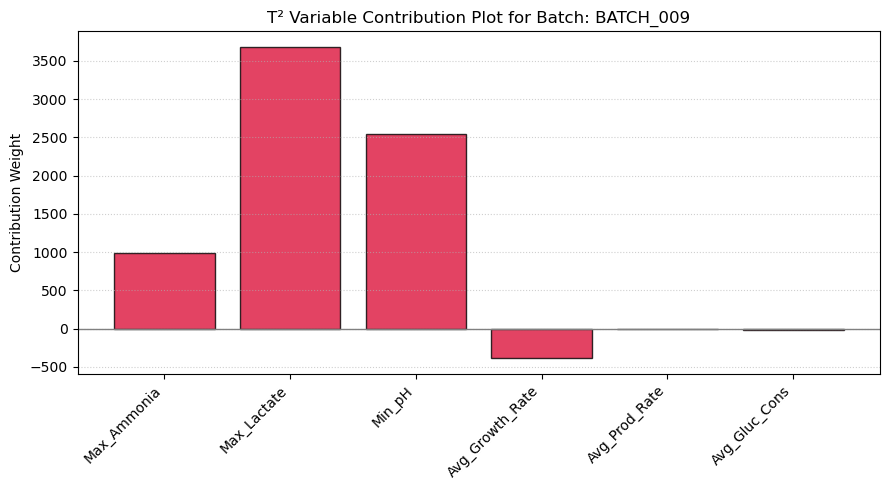

In [17]:
def plot_t2_contribution(df, batch_id, id_col, feature_cols, all_scaled, scores, pca_model):
    batch_idx = df[df[id_col] == batch_id].index[0]
    
    failed_batch_scaled = all_scaled[batch_idx] 
    contributions = np.zeros(len(feature_cols))

    for i in range(len(feature_cols)):
        contribution_i = 0
        for pc_idx in range(pca_model.n_components_):
            loading = pca_model.components_[pc_idx, i]
            score = scores[batch_idx, pc_idx]
            eigenvalue = pca_model.explained_variance_[pc_idx]
            contribution_i += score * loading / eigenvalue
        
        contributions[i] = failed_batch_scaled[i] * contribution_i

    plt.figure(figsize=(9, 5))
    plt.bar(feature_cols, contributions, color='crimson', edgecolor='black', alpha=0.8)
    plt.axhline(0, color='grey', lw=1)
    plt.title(f'T² Variable Contribution Plot for Batch: {batch_id}')
    plt.ylabel('Contribution Weight')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()

plot_t2_contribution(
    df=df_pca_final, 
    batch_id="BATCH_009", 
    id_col="Batch_ID", 
    feature_cols= feature_cols, 
    all_scaled=all_scaled, 
    scores=scores, 
    pca_model=pca_golden
)

## Hierarchical clustering

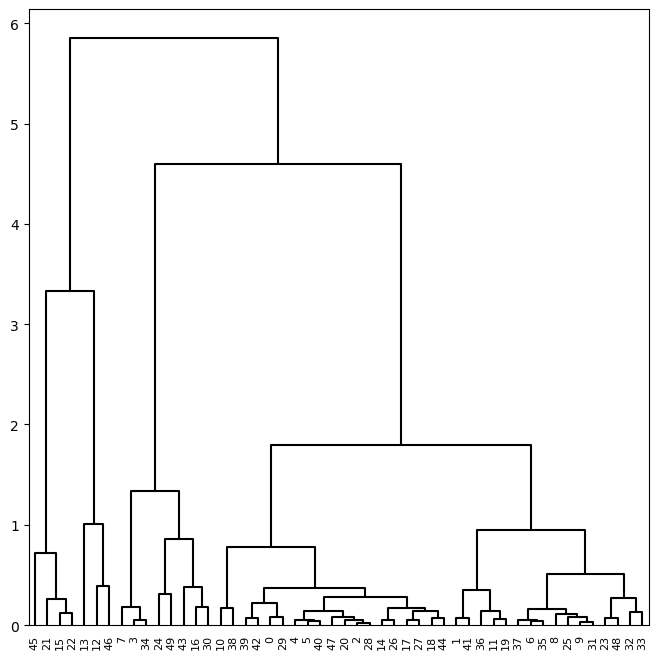

In [18]:
X = df_pca_plot[['PC1', 'PC2']].values
# 'complete' linkage matches your previous code
Z = linkage(X, method='complete')

# 3. Plot the dendrogram
fig, ax = plt.subplots(1, 1, figsize=(8, 8))

# mimic your cargs: color_threshold=-np.inf makes the whole tree one color
dendrogram(
    Z, 
    ax=ax, 
    color_threshold=-np.inf, 
    above_threshold_color='black'
)

plt.show()

## K-means cluster

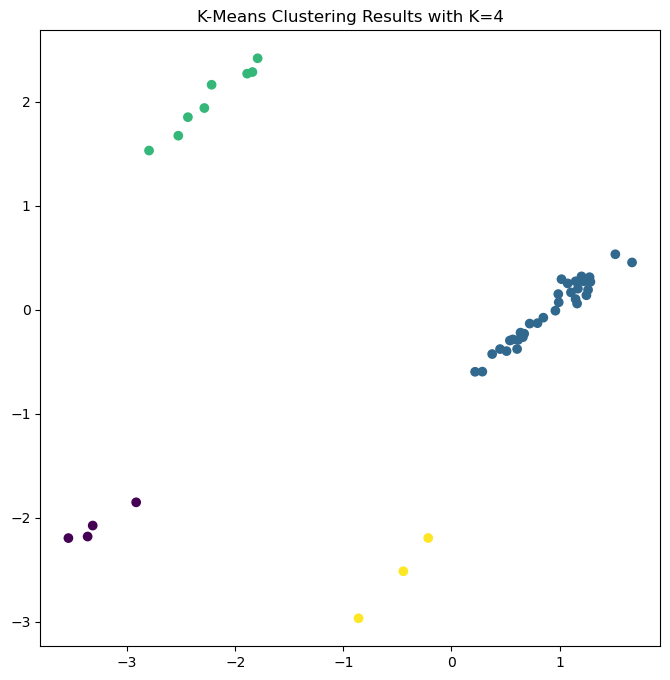

In [19]:
X = df_pca_plot[['PC1', 'PC2']].values
kmeans = KMeans(n_clusters=4, random_state=2, n_init=20).fit(X)

fig , ax = plt.subplots(1, 1, figsize=(8,8))
ax.scatter(X[:,0], X[:,1], c=kmeans.labels_)
ax.set_title("K-Means Clustering Results with K=4");

# Checkpoint Prediction Engine

In [20]:
query = """
SELECT *
FROM telemetry_aligned 
WHERE Hour <= 140
"""

telemetry_random_forest = con.execute(query).df()

query_2 = """
SELECT 
    o.Batch_ID, 
    o.Full_Titer, 
FROM outcomes o
"""
outcome_random_forest = con.execute(query_2).df()

In [21]:
telemetry_random_forest.head()

,Batch_ID,Hour,VCD,Glucose,Lactate,Ammonia,Product,pH,dt,Growth_Rate,Production_Rate,Consumption_Rate
0,BATCH_000,0.0,0.500817,51.167296,0.000000,0.000000,0.0,7.190487,NaN,NaN,NaN,NaN
1,BATCH_000,1.0,0.521538,51.060926,0.041431,0.006823,0.0,7.194654,1.0,0.039729,0.0,-0.203956
2,BATCH_000,2.0,0.562978,50.848184,0.078675,0.013051,0.0,7.199229,1.0,0.073610,0.0,-0.377886
3,BATCH_000,3.0,0.583698,50.741813,0.095203,0.015867,0.0,7.201719,1.0,0.035498,0.0,-0.182236
4,BATCH_000,4.0,0.604419,50.635443,0.111730,0.018684,0.0,7.204210,1.0,0.034281,0.0,-0.175989


In [37]:
def preparing_features(df_tel, df_out, checkpoint_hour):
    df_tel = df_tel.sort_values(by=['Batch_ID', 'Hour']).reset_index(drop=True)
    processed_features = []
    process_variables = ['VCD', 'Glucose', 'Lactate', 'Ammonia', 'Product', 'pH', 'Growth_Rate', 'Production_Rate', 'Consumption_Rate']
    
    for batch_id, batch_group in df_tel.groupby('Batch_ID'):
        # Limit data to given checkpoint hour (function argument) and put in chronological order
        group_to_hour = batch_group[batch_group['Hour'] <= checkpoint_hour].sort_values('Hour')
            
        # Creates a dataframe populated with the current batch_id of the loop
        batch_features = pd.DataFrame({'Batch_ID': [batch_id]})

        # Locate the checkpoint row
        matched_row = group_to_hour[group_to_hour['Hour'] == checkpoint_hour]

        # Extract the state and find its relative integer position in the group
        if not matched_row.empty:
            label = matched_row.index[0]
            checkpoint_index = group_to_hour.index.get_loc(label)

        # Calculating and/or storing current value, lag1 and 2, rolling average and standard deviation
        # cumulative sum
        for col in process_variables:
            batch_features[f'{col}_current'] = group_to_hour[col].iloc[checkpoint_index]
            
            batch_features[f'{col}_lag1'] = group_to_hour[col].iloc[checkpoint_index - 1]
            batch_features[f'{col}_lag2'] = group_to_hour[col].iloc[checkpoint_index - 2]
            
            short_window = group_to_hour[col].iloc[(checkpoint_index - 2):(checkpoint_index + 1)]
            batch_features[f'{col}_roll_mean3'] = short_window.mean()
            batch_features[f'{col}_roll_std3'] = short_window.std()
            
            if checkpoint_index >= 11:
                macro_window = group_to_hour.iloc[(checkpoint_index - 11):(checkpoint_index + 1)]
                hourly_rates = macro_window[col].diff().dropna() / macro_window['Hour'].diff().dropna()
                batch_features[f'{col}_avg_rate_12h'] = hourly_rates.mean()
            else:
                batch_features[f'{col}_avg_rate_12h'] = np.nan
                
            y = group_to_hour[col].values
            x = group_to_hour['Hour'].values
            if len(x) > 1:
                batch_features[f'{col}_cum_area'] = trapezoid(y, x)
            else:
                batch_features[f'{col}_cum_area'] = 0.0
                
        processed_features.append(batch_features)
              
    df_features_matrix = pd.concat(processed_features, ignore_index=True)
    df_modeling_set = pd.merge(df_features_matrix, df_out[['Batch_ID', 'Full_Titer']], on='Batch_ID', how='inner')

    
    return df_modeling_set

In [38]:
df_cp_75 = preparing_features(telemetry_random_forest,outcome_random_forest,75)
df_cp_100 = preparing_features(telemetry_random_forest,outcome_random_forest,100)

In [41]:
df_cp_75.head()

,Batch_ID,VCD_current,VCD_lag1,VCD_lag2,VCD_roll_mean3,VCD_roll_std3,VCD_avg_rate_12h,VCD_cum_area,Glucose_current,Glucose_lag1,...,Production_Rate_avg_rate_12h,Production_Rate_cum_area,Consumption_Rate_current,Consumption_Rate_lag1,Consumption_Rate_lag2,Consumption_Rate_roll_mean3,Consumption_Rate_roll_std3,Consumption_Rate_avg_rate_12h,Consumption_Rate_cum_area,Full_Titer
0,BATCH_000,7.362007,7.218465,6.931382,7.170618,0.219263,0.172120,210.418401,33.122978,33.500705,...,0.000177,NaN,-0.051308,-0.104656,-0.054495,-0.070153,0.029923,0.002281,NaN,2.607522
1,BATCH_001,7.227769,6.921413,6.768234,6.972472,0.233984,0.178950,205.769842,33.603693,34.385671,...,0.000376,NaN,-0.108191,-0.056490,-0.119634,-0.094772,0.033643,-0.006217,NaN,2.275756
2,BATCH_002,7.077603,6.932021,6.640856,6.883493,0.222381,0.170716,204.688232,13.448520,13.819620,...,0.000192,NaN,-0.052433,-0.107068,-0.092246,-0.083916,0.028254,-0.000545,NaN,1.661988
3,BATCH_003,7.187819,6.900907,6.757452,6.948726,0.219132,0.171197,205.283723,12.819203,13.480594,...,0.000352,NaN,-0.092016,-0.047921,-0.097876,-0.079271,0.027308,0.000878,NaN,1.666431
4,BATCH_004,7.273261,6.947273,6.784278,7.001604,0.248978,0.168101,210.655389,33.099815,33.898792,...,0.000399,NaN,-0.109851,-0.057503,-0.123131,-0.096828,0.034698,-0.002681,NaN,2.592127


In [69]:
def training_random_forest(df, tree_number):
    y = df["Full_Titer"]
    X = df.drop(columns=["Full_Titer", "Batch_ID"]).copy()
    (X_train , X_test , y_train , y_test) = skm.train_test_split(X, y , test_size=0.6,random_state=0)
    
    checkpoint_model = RFR(max_features=X_train.shape[1], n_estimators=tree_number, random_state=0)
    checkpoint_model.fit(X_train , y_train)
    
    fig , ax = plt.subplots(1, 1, figsize=(8,8))
    y_hat_bag = checkpoint_model.predict(X_test)
    ax.scatter(y_hat_bag , y_test)
    mse_test = np.mean((y_test - y_hat_bag)**2)

    feature_imp = pd.DataFrame(
    {'importance':checkpoint_model.feature_importances_},
    index=X.columns)
    
    feature_imp = feature_imp.sort_values(by='importance', ascending=False)

    return mse_test, feature_imp

(np.float64(0.049235536644373606),
                              importance
 Consumption_Rate_roll_mean3    0.118432
 Glucose_cum_area               0.103080
 Glucose_current                0.094639
 Glucose_lag1                   0.083722
 Growth_Rate_roll_mean3         0.070059
 ...                                 ...
 VCD_roll_mean3                 0.000094
 Production_Rate_lag1           0.000077
 Growth_Rate_cum_area           0.000000
 Production_Rate_cum_area       0.000000
 Consumption_Rate_cum_area      0.000000
 
 [63 rows x 1 columns])

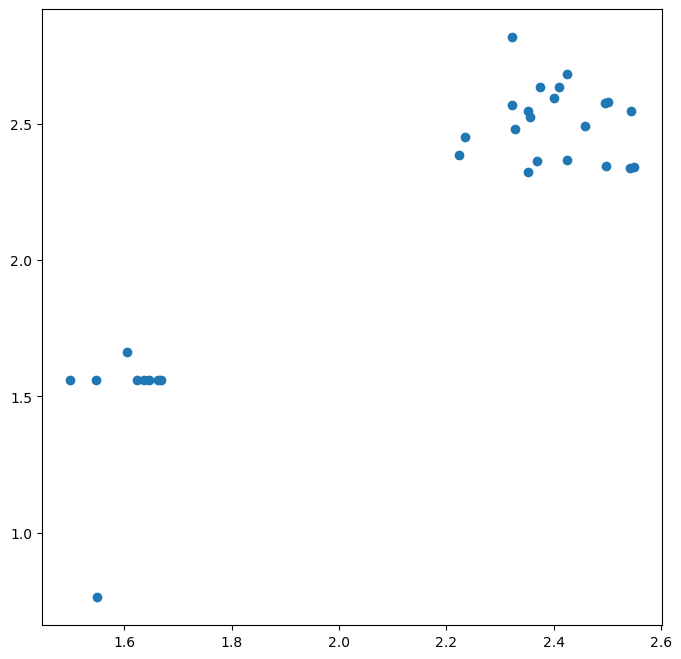

In [71]:
training_random_forest(df_cp_100, 100)